In [42]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pickle

In [30]:
spam_data=pd.read_csv("spam.csv",encoding="latin-1")
y=spam_data["v1"]

X=spam_data["v2"]


In [31]:
#covert string  in data into numerical
y=y.map({"ham":0,
        "spam":1})

tfid=TfidfVectorizer()
X=tfid.fit_transform(X)


In [32]:
#split data into train and test as well as validation data
x_train,x_,y_train,y_=train_test_split(X,y,test_size=0.4,random_state=55)
x_val,x_test,y_val,y_test=train_test_split(x_,y_,test_size=0.5,random_state=55)

In [33]:
#list of constant C
C_list = [0.01, 0.1, 1, 10, 100]


In [34]:
#define list of train and validation accuracy 
train_accuracy_list=[]
val_accuracy_list=[]

#check most optimal c value of model
for C in C_list:

    #train Logistic model 
    model=LogisticRegression(C=C)
    model.fit(x_train,y_train)

    #predict train and validation data
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)

    #find accuracy of train and test 
    train_acc=accuracy_score(y_train,y_train_predict)
    val_acc=accuracy_score(y_val,y_val_predict)

    #add accuracy to list 
    train_accuracy_list.append(train_acc)
    val_accuracy_list.append(val_acc)
    
    
    

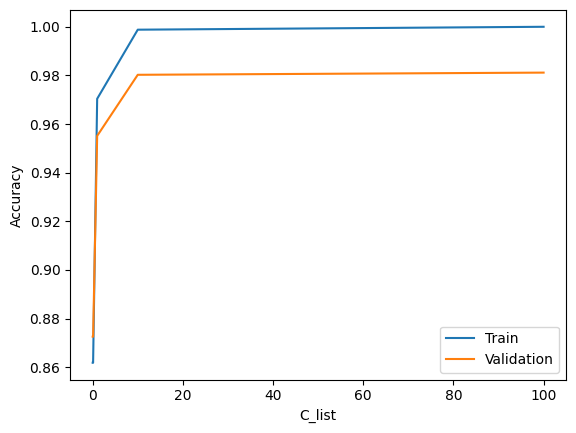

In [35]:
#plot graph
plt.plot(C_list,train_accuracy_list)
plt.plot(C_list,val_accuracy_list)
plt.xlabel('C_list')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])


In [37]:
#find optimal c value
index=np.argmax(val_accuracy_list)
C=C_list[index]


In [38]:
max_iter_list=[150,90,100,150,200,300,400]

In [39]:
#define list of train and validation accuracy
train_accuracy_list=[]
val_accuracy_list=[]
for max_iter in max_iter_list:

    #train model
    model=LogisticRegression(C=C,max_iter=max_iter)

    #predict train and validation data
    model.fit(x_train,y_train)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)

    #find accuracy of train and validation data
    train_acc=accuracy_score(y_train,y_train_predict)
    val_acc=accuracy_score(y_val,y_val_predict)

    #add accuracy to list
    train_accuracy_list.append(train_acc)
    val_accuracy_list.append(val_acc)
    
    
    

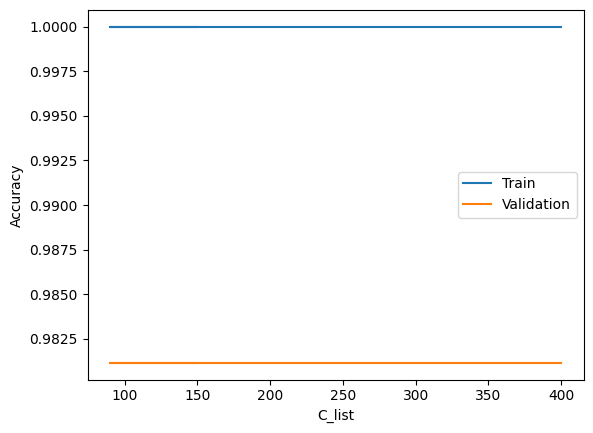

In [40]:
#plot graph
plt.plot(max_iter_list,train_accuracy_list)
plt.plot(max_iter_list,val_accuracy_list)
plt.xlabel('C_list')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])


In [ ]:
#train model with optimal hyper parameter
model=LogisticRegression(C=C)
model.fit(x_train,y_train)

In [43]:
#Save the trained model as a pickle file for future predictions
pickle.dump(model,open("spam_Logistic_regression.pkl","wb"))